# Word Embeddings

## Let's train a simple Word2Vec model

In [1]:
!sudo apt update && sudo apt install -y gcc g++

Get:1 http://ports.ubuntu.com/ubuntu-ports jammy InRelease [270 kB]
Get:2 http://ports.ubuntu.com/ubuntu-ports jammy-updates InRelease [119 kB]
Get:3 http://ports.ubuntu.com/ubuntu-ports jammy-backports InRelease [109 kB]
Get:4 http://ports.ubuntu.com/ubuntu-ports jammy-security InRelease [110 kB]
Get:5 http://ports.ubuntu.com/ubuntu-ports jammy/restricted arm64 Packages [24.2 kB]
Get:6 http://ports.ubuntu.com/ubuntu-ports jammy/main arm64 Packages [1758 kB]
Get:7 http://ports.ubuntu.com/ubuntu-ports jammy/multiverse arm64 Packages [224 kB]
Get:8 http://ports.ubuntu.com/ubuntu-ports jammy/universe arm64 Packages [17.2 MB]
Get:9 http://ports.ubuntu.com/ubuntu-ports jammy-updates/restricted arm64 Packages [1623 kB]m
Get:10 http://ports.ubuntu.com/ubuntu-ports jammy-updates/main arm64 Packages [1695 kB]m
Get:11 http://ports.ubuntu.com/ubuntu-ports jammy-updates/multiverse arm64 Packages [29.2 kB]
Get:12 http://ports.ubuntu.com/ubuntu-ports jammy-updates/universe arm64 Packages [1299 kB]
G

In [2]:
!pip install gensim scikit-learn bs4 pandas matplotlib fasttext pandas scipy==1.12.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 1.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 3.8 MB/s eta 0:00:00a 0:00:01
  Using cached pybind11-2.12.0-py3-none-any.whl.metadata (9.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.7/34.7 MB 16.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 24.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 29.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 29.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 26.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.1/302.1 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import re

lines = []
counter = 0
corpus_directory = "work/corpus"

for filename in os.listdir(corpus_directory):
    if filename.endswith(".txt"):
        with open(os.path.join(corpus_directory, filename), "r") as f:
            content = f.read()

            # replace newlines and surrounding spaces with a single newline
            content = re.sub(r'\s*\n+\s*', ' ', content)

            lines.append(content)
        
        counter += 1
        
        if counter == 5000:
            break

pandas.DataFrame(lines[:3], columns=["line"])

Tokenize the lines

In [6]:
from gensim.utils import tokenize
from gensim.parsing.preprocessing import remove_stopwords, preprocess_documents


sentences = preprocess_documents(lines)
pandas.DataFrame(zip(lines[:3], sentences[:3]), columns=["line", "tokens"])

,line,tokens
0,The Self-Strengthening Movement (Chinese: 洋務運動...,"[self, strengthen, movement, chines, 洋務運動, 自強運..."
1,Scent marks are what animals leave when they a...,"[scent, mark, anim, leav, mark, territori, lea..."
2,La Chapelle-Saint-Aubin is a commune. It is fo...,"[chapel, saint, aubin, commun, region, pai, lo..."


Train the model

In [7]:
from gensim.models import Word2Vec
w2v_model = Word2Vec(sentences=sentences, min_count=2)

What does the vocabulary look like?

In [8]:
pandas.DataFrame(w2v_model.wv.index_to_key[:5], columns=["term"])

,term
0,peopl
1,state
2,citi
3,call
4,river


Let's see some similarities

In [24]:
from gensim.parsing.preprocessing import preprocess_string

pandas.DataFrame(w2v_model.wv.most_similar(preprocess_string("china"), topn=10), columns=["term", "similarity"])

,term,similarity
0,czech,0.994966
1,guinea,0.992382
2,iran,0.991932
3,turkei,0.991693
4,cypru,0.991403
5,saxoni,0.990675
6,union,0.989830
7,economi,0.989509
8,cuba,0.989173
9,estim,0.988993


Word2Vec cannot handle unknown words

In [10]:
try:
    w2v_model.wv.similar_by_word("blubbergurken")
except KeyError as e:
    display(e)

KeyError("Key 'blubbergurken' not present in vocabulary")

## fastText

In [11]:
from gensim.models import FastText
from gensim.utils import tokenize
from gensim.parsing.preprocessing import preprocess_string
ft_model = FastText()
corpus = [list(tokenize(line, lowercase=True, deacc=True)) for line in lines]
ft_model.build_vocab(corpus_iterable=corpus)
ft_model.train(corpus_iterable=corpus, total_examples=len(corpus), epochs=100)

(35727895, 53073600)

In [25]:
pandas.DataFrame(ft_model.wv.most_similar("china", topn=10), columns=["term", "similarity"])

,term,similarity
0,chin,0.709014
1,malaysia,0.566806
2,japan,0.547955
3,chinese,0.543125
4,chi,0.541542
5,indonesia,0.540330
6,eurasia,0.536715
7,xia,0.535368
8,alania,0.526709
9,india,0.524388


## A more complex model

Gensim provides a lot of pretrained models

In [13]:
import gensim.downloader
pandas.DataFrame(list(gensim.downloader.info()['models'].keys()), columns=["model"])

,model
0,fasttext-wiki-news-subwords-300
1,conceptnet-numberbatch-17-06-300
2,word2vec-ruscorpora-300
3,word2vec-google-news-300
4,glove-wiki-gigaword-50
5,glove-wiki-gigaword-100
6,glove-wiki-gigaword-200
7,glove-wiki-gigaword-300
8,glove-twitter-25
9,glove-twitter-50


We'll pick one that was trained on Wikipedia.

In [14]:
wiki_model = gensim.downloader.load('glove-wiki-gigaword-50')

[=================---------------------------------] 35.5% 23.4/66.0MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Most simply, it can tell you the difference between two words.

In [15]:
wiki_model.similarity('woman', 'man')

0.8860338

In [16]:
wiki_model.similarity('cat', 'man')

0.62407094

It can list the most similar words for an input word.

In [17]:
pandas.DataFrame(wiki_model.most_similar('twitter'), columns=["term", "similarity"])

,term,similarity
0,facebook,0.933305
1,myspace,0.880137
2,youtube,0.843066
3,blog,0.826206
4,blogs,0.806482
5,blogging,0.797067
6,tumblr,0.790109
7,email,0.778261
8,tweets,0.760454
9,e-mail,0.753873


It can do actual vector calculations.

In [18]:
pandas.DataFrame(wiki_model.most_similar(positive=['woman', 'king'], negative=['man']), columns=["term", "similarity"])

,term,similarity
0,queen,0.852360
1,throne,0.766433
2,prince,0.759214
3,daughter,0.747388
4,elizabeth,0.746022
5,princess,0.742457
6,kingdom,0.733741
7,monarch,0.721449
8,eldest,0.718486
9,widow,0.709943


Play odd man out.

In [19]:
wiki_model.doesnt_match("breakfast cereal dinner lunch".split())

'cereal'

In [20]:
wiki_model.doesnt_match("cat dog man elephant".split())

'man'

To visualize this on a larger scale, let's generate similar words for five input words.

In [21]:
from gensim.parsing.preprocessing import preprocess_string

words = ["machine", "learning", "information", "retrieval", "computer", "science"]
semantically_similar_words = {word: [item[0] for item in wiki_model.most_similar([word], topn=5)]
                  for word in words}
pandas.DataFrame([[term, similars] for (term, similars) in semantically_similar_words.items()], columns=["term", "similar terms"])

,term,similar terms
0,machine,"[machines, device, using, gun, used]"
1,learning,"[teaching, skills, experience, practical, know..."
2,information,"[source, data, sources, provided, documents]"
3,retrieval,"[archiving, visualization, synchronization, re..."
4,computer,"[computers, software, technology, electronic, ..."
5,science,"[sciences, research, institute, studies, physics]"


Flatten the list.

In [22]:
all_similar_words = sum([[k] + v for k, v in semantically_similar_words.items()], [])

pandas.DataFrame(all_similar_words, columns=["term"])

,term
0,machine
1,machines
2,device
3,using
4,gun
5,used
6,learning
7,teaching
8,skills
9,experience


Map the embedding vectors on a 2d space, and clear clusters appear.

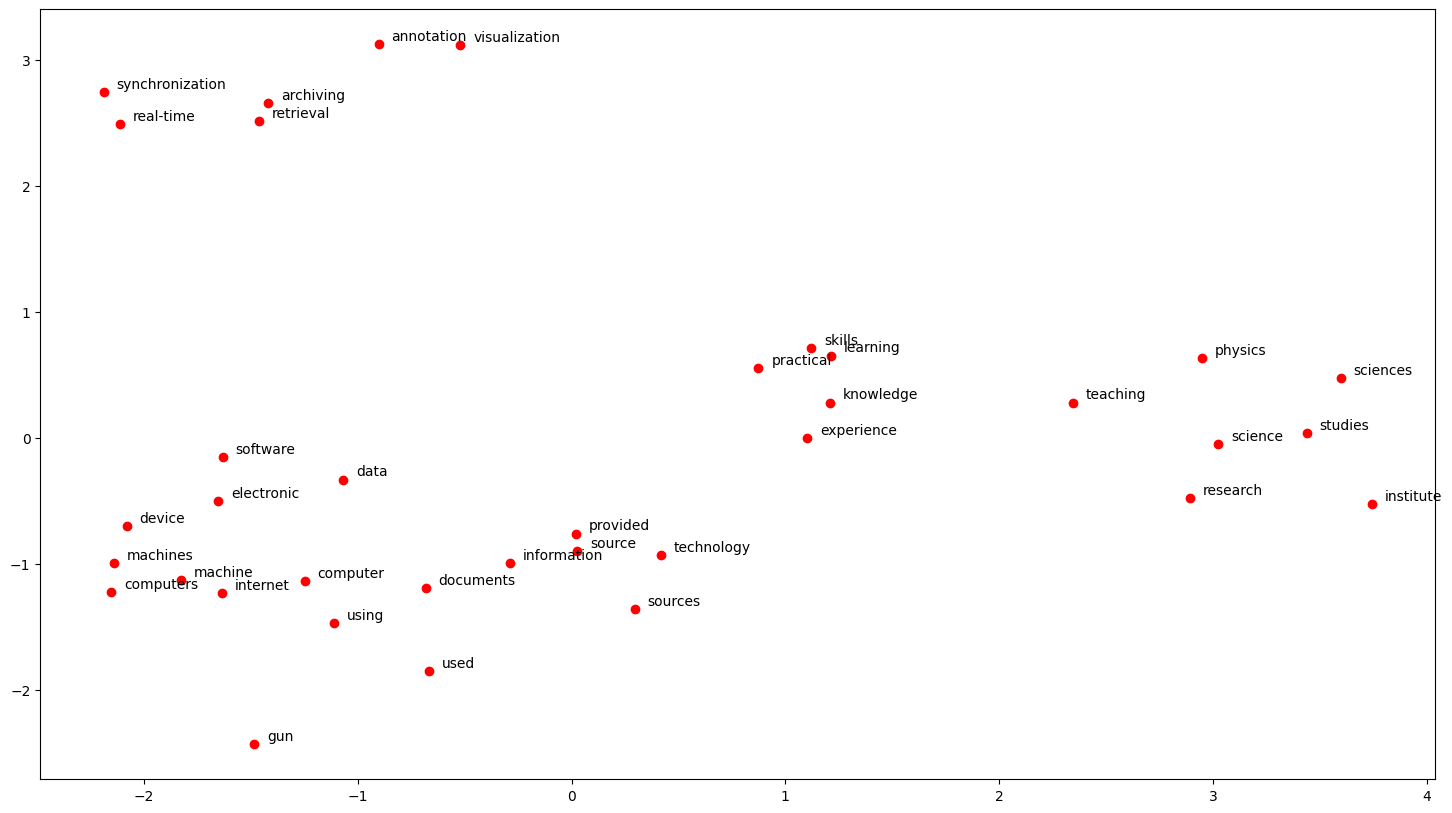

In [23]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

word_vectors = wiki_model[all_similar_words]

pca = PCA(n_components=2)

p_comps = pca.fit_transform(word_vectors)
word_names = all_similar_words

plt.figure(figsize=(18, 10))
plt.scatter(p_comps[:, 0], p_comps[:, 1], c='red')

for word_names, x, y in zip(word_names, p_comps[:, 0], p_comps[:, 1]):
    plt.annotate(word_names, xy=(x+0.06, y+0.03), xytext=(0, 0), textcoords='offset points')